In [ ]:
from tensorflow.keras import layers
from tensorflow import keras
import tensorflow as tf

from sklearn.model_selection import train_test_split

from ast import literal_eval
# is used for safely evaluating strings containing Python literals or container displays
# (e.g., lists, dictionaries) to their corresponding Python obb[poiuy1`234e5rt6y7i90o-p=[2wszjects.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

: 

In [ ]:
import pandas as pd

df = pd.read_csv(""C:\Users\histe\Desktop\Recommendation System\arxiv_data_210930-054931.csv"")

df.head()

,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...


# ***DATA CLEANING AND PREPROCESSING***

In [10]:
df.shape

(56181, 3)

In [11]:
df.isnull().sum()

,0
terms,0
titles,0
abstracts,0


In [12]:
df.duplicated().sum()

np.int64(15054)

In [13]:
# getting unique labels
from ast import literal_eval
labels_column = df['terms'].apply(literal_eval)
labels = labels_column.explode().unique()
print("labels :",labels)
print("length :",len(labels))

labels : ['cs.LG' 'cs.AI' 'cs.CR' ... 'D.1.3; G.4; I.2.8; I.2.11; I.5.3; J.3'
 '68T07, 68T45, 68T10, 68T50, 68U35' 'I.2.0; G.3']
length : 1177


In [14]:
# remove duplicate entries based on the "titles" (terms) column
# This filters the DataFrame, keeping only the rows where the titles are not duplicated.
df = df[~df['titles'].duplicated()]
print(f"There are {len(df)} rows in the deduplicated dataset.")
# There are some terms with occurrence as low as 1.
print(sum(df['terms'].value_counts()==1))
# how many unique terms
print(df['terms'].nunique())

There are 41105 rows in the deduplicated dataset.
2503
3401


In [15]:
# Filtering the rare terms. (it keeps only those rows where the "terms" value occurs more than once in the original DataFrame.)
df_filtered = df.groupby('terms').filter(lambda x: len(x) > 1)
df_filtered.shape

(38602, 3)

In [16]:
# It evaluates the given string containing a Python literal or container display (e.g., a list or dictionary) and returns the corresponding Python object.
df_filtered['terms'] = df_filtered['terms'].apply(lambda x: literal_eval(x))
df_filtered['terms'].values[:3]

array([list(['cs.LG']), list(['cs.LG', 'cs.AI']),
       list(['cs.LG', 'cs.CR', 'stat.ML'])], dtype=object)

# ***Train Test slpit***

In [17]:
from sklearn.model_selection import train_test_split
test_split = 0.1

# Initial train and test split.
# The stratify parameter ensures that the splitting is done in a way that preserves the same distribution of labels (terms) in both the training and test sets.
train_df, test_df = train_test_split(df_filtered,test_size=test_split,stratify=df_filtered["terms"].values,)

# Splitting the test set further into validation
# and new test sets.
val_df = test_df.sample(frac=0.5)
test_df.drop(val_df.index, inplace=True)

print(f"Number of rows in training set: {len(train_df)}")
print(f"Number of rows in validation set: {len(val_df)}")
print(f"Number of rows in test set: {len(test_df)}")

Number of rows in training set: 34741
Number of rows in validation set: 1930
Number of rows in test set: 1931


In [18]:
# creates a TensorFlow RaggedTensor (terms) from the values in the "terms" column of the train_df DataFrame. A RaggedTensor is a tensor with non-uniform shapes
terms = tf.ragged.constant(train_df['terms'].values)
# This line creates a StringLookup layer in TensorFlow. The purpose of this layer is to map strings to integer indices and vice versa. The output_mode="multi_hot" indicates that the layer will output a multi-hot encoded representation of the input strings.
lookup = tf.keras.layers.StringLookup(output_mode='multi_hot')
# This step adapts the StringLookup layer to the unique values in the "terms" column, building the vocabulary.
lookup.adapt(terms)
# retrieve vocabulary
vocab = lookup.get_vocabulary()

print("Vocabulary:\n")
print(vocab)

Vocabulary:

['[UNK]', np.str_('cs.CV'), np.str_('cs.LG'), np.str_('stat.ML'), np.str_('cs.AI'), np.str_('eess.IV'), np.str_('cs.RO'), np.str_('cs.CL'), np.str_('cs.NE'), np.str_('cs.GR'), np.str_('cs.CR'), np.str_('math.OC'), np.str_('eess.SP'), np.str_('cs.SI'), np.str_('cs.MM'), np.str_('cs.SY'), np.str_('cs.IR'), np.str_('eess.SY'), np.str_('cs.MA'), np.str_('cs.HC'), np.str_('math.IT'), np.str_('cs.IT'), np.str_('cs.DC'), np.str_('stat.AP'), np.str_('cs.CY'), np.str_('stat.ME'), np.str_('stat.TH'), np.str_('math.ST'), np.str_('eess.AS'), np.str_('cs.SD'), np.str_('cs.DS'), np.str_('q-bio.QM'), np.str_('q-bio.NC'), np.str_('stat.CO'), np.str_('cs.CG'), np.str_('cs.GT'), np.str_('cs.NI'), np.str_('math.NA'), np.str_('cs.SE'), np.str_('cs.NA'), np.str_('I.2.6'), np.str_('physics.chem-ph'), np.str_('cs.DB'), np.str_('physics.comp-ph'), np.str_('cond-mat.dis-nn'), np.str_('q-bio.BM'), np.str_('cs.LO'), np.str_('math.PR'), np.str_('cs.PL'), np.str_('68T45'), np.str_('cs.AR'), np.str_('p

In [19]:
sample_label = train_df["terms"].iloc[0]
print(f"Original label: {sample_label}")

label_binarized = lookup([sample_label])
print(f"Label-binarized representation: {label_binarized}")

Original label: ['cs.CV']
Label-binarized representation: [[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [20]:
# following lines::
# which is used for automatic adjustment of resource usage by TensorFlow's data loading pipeline.

#max_seqlen: Maximum sequence length. It indicates the maximum length allowed for sequences.
max_seqlen = 150
#batch_size: Batch size. It specifies the number of samples to use in each iteration.
batch_size = 128
#padding_token: A token used for padding sequences.
padding_token = "<pad>"
#auto = tf.data.AUTOTUNE: auto is assigned the value tf.data.AUTOTUNE,
auto = tf.data.AUTOTUNE

def make_dataset(dataframe, is_train=True):
    # creating sequences of labesls
    labels = tf.ragged.constant(dataframe["terms"].values)
    #This line uses the previously defined lookup layer to convert the ragged tensor of labels into a binarized representation. The resulting label_binarized is a NumPy array.
    label_binarized = lookup(labels).numpy()
    # creating sequences of text.
    dataset = tf.data.Dataset.from_tensor_slices((dataframe["abstracts"].values, label_binarized))
    # shuffling data basis on condition
    dataset = dataset.shuffle(batch_size * 10) if is_train else dataset
    return dataset.batch(batch_size)

"""
In summary, the make_dataset function is designed to create a
dataset suitable for training a model. It takes a dataframe as input,
assumes it has "abstracts" and "terms" columns, and creates a dataset of
batches where each batch consists of abstract
sequences and their corresponding binarized label sequences.
"""

'\nIn summary, the make_dataset function is designed to create a\ndataset suitable for training a model. It takes a dataframe as input,\nassumes it has "abstracts" and "terms" columns, and creates a dataset of\nbatches where each batch consists of abstract\nsequences and their corresponding binarized label sequences.\n'

In [21]:
train_dataset = make_dataset(train_df, is_train=True)
validation_dataset = make_dataset(val_df, is_train=False)
test_dataset = make_dataset(test_df, is_train=False)

In [22]:
# Define the invert_multi_hot function
def invert_multi_hot(multi_hot_labels):
    """
    Converts a multi-hot encoded label back to its original terms.

    Args:
        multi_hot_labels: A multi-hot encoded label (numpy array).

    Returns:
        A list of original terms.
    """
    # Use the lookup layer's inverse vocabulary lookup
    return [vocab[i] for i, hot in enumerate(multi_hot_labels) if hot == 1]

# This code snippet is iterating through batches of the training dataset and printing the abstract text along with the corresponding labels.
text_batch, label_batch = next(iter(train_dataset))
for i, text in enumerate(text_batch[:5]):
    label = label_batch[i].numpy()[None, ...]
    print(f"Abstract: {text}")
    print(f"Label(s): {invert_multi_hot(label[0])}")
    print(" ")

Abstract: b'We present an attention-based model for recognizing multiple objects in\nimages. The proposed model is a deep recurrent neural network trained with\nreinforcement learning to attend to the most relevant regions of the input\nimage. We show that the model learns to both localize and recognize multiple\nobjects despite being given only class labels during training. We evaluate the\nmodel on the challenging task of transcribing house number sequences from\nGoogle Street View images and show that it is both more accurate than the\nstate-of-the-art convolutional networks and uses fewer parameters and less\ncomputation.'
Label(s): [np.str_('cs.CV'), np.str_('cs.LG'), np.str_('cs.NE')]
 
Abstract: b'Deep Neural Network (DNN) is powerful but computationally expensive and\nmemory intensive, thus impeding its practical usage on resource-constrained\nfront-end devices. DNN pruning is an approach for deep model compression, which\naims at eliminating some parameters with tolerable perf

In [23]:
# This code calculates the size of the vocabulary in the "abstracts" column of the train_df DataFrame.

# Creating vocabulary with uniques words
vocabulary = set()
train_df["abstracts"].str.lower().str.split().apply(vocabulary.update)
vocabulary_size = len(vocabulary)
print(vocabulary_size)

158713


# ***Text Vectorisation***

In [24]:
# Initializes a TextVectorization layer
text_vectorizer = layers.TextVectorization(max_tokens=vocabulary_size,ngrams=2,output_mode="tf_idf")
# `TextVectorization` layer needs to be adapted as per the vocabulary from our
# training set.
text_vectorizer.adapt(train_dataset.map(lambda text, label: text))

In [25]:
"""
Mapping Vectorization to Datasets: The code maps the text vectorization operation to
each element of the training, validation, and test datasets. This ensures that the text
data in each dataset is transformed into numerical vectors using the adapted TextVectorization layer.
The num_parallel_calls parameter is used to parallelize the mapping process, and prefetch is
applied to prefetch data batches
for better performance.
"""
train_dataset = train_dataset.map(lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto).prefetch(auto)
validation_dataset = validation_dataset.map(lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto).prefetch(auto)
test_dataset = test_dataset.map(lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto).prefetch(auto)

# ***Model Training***

In [26]:
# creating shallow_mlp_model  (MLP)
from tensorflow.keras.callbacks import EarlyStopping

# Creating shallow_mlp_model (MLP) with dropout layers
model1 = keras.Sequential([
    # First hidden layer: 512 neurons, ReLU activation function, with dropout.
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),  # Adding dropout for regularization.

    # Second hidden layer: 256 neurons, ReLU activation function, with dropout.
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),  # Adding dropout for regularization.

    # Output layer: The number of neurons equals the vocabulary size (output vocabulary of the StringLookup layer), with a sigmoid activation function.
    layers.Dense(lookup.vocabulary_size(), activation='sigmoid')
])

# Compile the model
model1.compile(loss="binary_crossentropy", optimizer='adam', metrics=['binary_accuracy'])

# Add early stopping
# Number of epochs with no improvement after which training will be stopped.
# Restore weights from the epoch with the best value of the monitored quantity.
early_stopping = EarlyStopping(patience=5,restore_best_weights=True)

# Train the model
# Add early stopping callback.verbose=1
history = model1.fit(train_dataset,validation_data=validation_dataset,epochs=10,callbacks=[early_stopping])

Epoch 1/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 51s 160ms/step - binary_accuracy: 0.9484 - loss: 0.1215 - val_binary_accuracy: 0.9946 - val_loss: 0.0187
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - binary_accuracy: 0.9947 - loss: 0.0190 - val_binary_accuracy: 0.9947 - val_loss: 0.0189
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 41s 148ms/step - binary_accuracy: 0.9957 - loss: 0.0142 - val_binary_accuracy: 0.9945 - val_loss: 0.0192
Epoch 4/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - binary_accuracy: 0.9965 - loss: 0.0116 - val_binary_accuracy: 0.9946 - val_loss: 0.0194
Epoch 5/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - binary_accuracy: 0.9971 - loss: 0.0099 - val_binary_accuracy: 0.9945 - val_loss: 0.0201
Epoch 6/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - binary_accuracy: 0.9974 - loss: 0.0087 - val_binary_accuracy: 0.9945 - val_loss: 0.0210


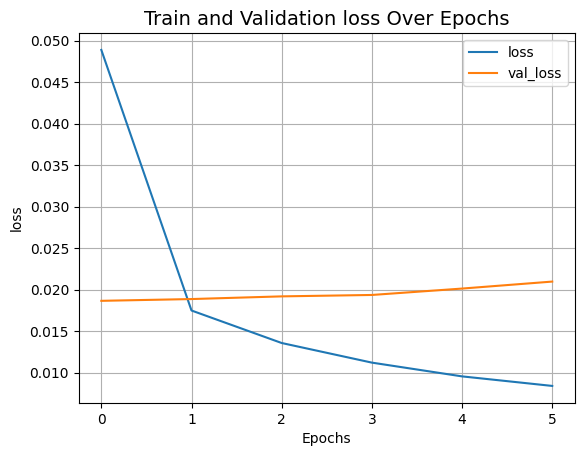

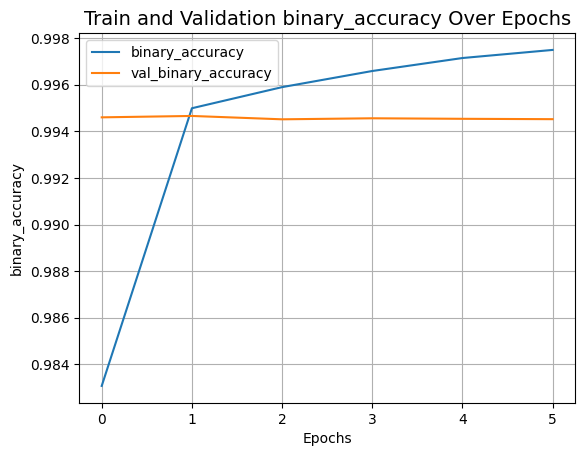

In [27]:
# plotting loss
def plot_result(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_result("loss")
plot_result("binary_accuracy")

# `***Model Evaluation***`

In [28]:
# model evaltuation on test and val dataset
_, binary_acc1 = model1.evaluate(test_dataset)
_, binary_acc2 = model1.evaluate(validation_dataset)

print(f"Categorical accuracy on the test set: {round(binary_acc1 * 100, 2)}%.")
print(f"Categorical accuracy on the validation set: {round(binary_acc2 * 100, 2)}%.")

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - binary_accuracy: 0.9946 - loss: 0.0182
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - binary_accuracy: 0.9946 - loss: 0.0185
Categorical accuracy on the test set: 99.44%.
Categorical accuracy on the validation set: 99.46%.


# ***Save Model And Text Vectorizer***

In [29]:
import pickle
# Save the model
model1.save("models/model.h5")

# Save the configuration of the text vectorizer
saved_text_vectorizer_config = text_vectorizer.get_config()
with open("models/text_vectorizer_config.pkl", "wb") as f:
    pickle.dump(saved_text_vectorizer_config, f)

# Save the weights of the text vectorizer (includes vocabulary and IDF weights)
saved_text_vectorizer_weights = text_vectorizer.get_weights()
with open("models/text_vectorizer_weights.pkl", "wb") as f:
    pickle.dump(saved_text_vectorizer_weights, f)

# Save the vocabulary (optional, as it's included in weights, but good for clarity)
with open("models/vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

# ***Load Model And Text Vectorizer***

In [30]:
from tensorflow import keras
import pickle
from tensorflow.keras.layers import TextVectorization
import tensorflow as tf
import numpy as np

# Load the model
loaded_model = keras.models.load_model("models/model.h5")

# Load the configuration of the text vectorizer
with open("/content/models/text_vectorizer_config.pkl", "rb") as f:
    saved_text_vectorizer_config = pickle.load(f)

# Create a new TextVectorization layer with the saved configuration
loaded_text_vectorizer = TextVectorization.from_config(saved_text_vectorizer_config)

# Load the saved weights into the new TextVectorization layer
with open("/content/models/text_vectorizer_weights.pkl", "rb") as f:
    weights = pickle.load(f)
    loaded_text_vectorizer.set_weights(weights)

# Adapt the loaded vectorizer with the training data abstracts to initialize the lookup table
loaded_text_vectorizer.adapt(train_df['abstracts'].values)

# Load the vocabulary (optional)
with open("/content/models/vocab.pkl", "rb") as f:
    loaded_vocab = pickle.load(f)

In [31]:
import os

# Create the directory if it doesn't exist
if not os.path.exists("models"):
    os.makedirs("models")

In [32]:
# Load the vocabulary
# with open("models/vocab.pkl", "rb") as f:
#     loaded_vocab = pickle.load(f)

# ***Model Prediction***

In [33]:
def invert_multi_hot(encoded_labels):
    """Reverse a single multi-hot encoded label to a tuple of vocab terms."""
    hot_indices = np.argwhere(encoded_labels == 1.0)[..., 0]
    return np.take(loaded_vocab, hot_indices)

In [34]:
def predict_category(abstract, model, vectorizer, label_lookup):
    # Preprocess the abstract using the loaded text vectorizer
    preprocessed_abstract = vectorizer([abstract])

    # Make predictions using the loaded model
    predictions = model.predict(preprocessed_abstract)

    # Convert predictions to human-readable labels
    predicted_labels = label_lookup(np.round(predictions).astype(int)[0])

    return predicted_labels

In [35]:
# Save the entire model in the SavedModel format
model1.save("models/full_model.keras")

In [36]:
# Load the entire model
loaded_full_model = keras.models.load_model("models/full_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [37]:
loaded_full_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    81,261,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 165)            │        42,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,870,604 (621.30 MB)

 Trainable params: 81,435,301 (310.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,435,303 (310.65 MB)

Now you can use `loaded_full_model` directly for predictions, as it includes the text vectorization layer.

In [38]:
def predict_category(abstract, model, vectorizer, label_lookup):
    # Preprocess the abstract using the loaded text vectorizer
    preprocessed_abstract = vectorizer([abstract]).numpy().astype('float32')

    # Make predictions using the loaded model
    predictions = model.predict(preprocessed_abstract)

    # Convert predictions to human-readable labels
    predicted_labels = invert_multi_hot(np.round(predictions).astype(int)[0])

    return predicted_labels

In [52]:
# Example usage with the loaded full model and loaded text vectorizer
new_abstract = '''Deep learning is a class of machine learning which performs much better on unstructured data. Deep learning techniques are outperforming current machine learning techniques. It enables computational models to learn features progressively from data at multiple levels. The popularity of deep learning amplified as the amount of data available increased as well as the advancement of hardware that provides powerful computers. This article comprises the evolution of deep learning, various approaches to deep learning, architectures of deep learning, methods, and applications.'''

# Preprocess the abstract using the loaded_text_vectorizer before passing it to the model
preprocessed_new_abstract = loaded_text_vectorizer([new_abstract]).numpy().astype('float32')

# Make predictions using the loaded_full_model with the preprocessed abstract
predictions = loaded_full_model.predict(preprocessed_new_abstract)

# Convert predictions to human-readable labels using the original vocab
predicted_labels = invert_multi_hot(np.round(predictions).astype(int)[0])

print("Predicted Categories:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Categories: ['cs.LG' 'stat.ML']


# ***Recommendation System***

In [40]:
df.drop(columns = ["terms","abstracts"], inplace = True)

In [41]:
df.drop_duplicates(inplace= True)
df.reset_index(drop= True,inplace = True)

In [42]:
pd.set_option('display.max_colwidth', None)
df

,titles
0,Multi-Level Attention Pooling for Graph Neural Networks: Unifying Graph Representations with Multiple Localities
1,Decision Forests vs. Deep Networks: Conceptual Similarities and Empirical Differences at Small Sample Sizes
2,Power up! Robust Graph Convolutional Network via Graph Powering
3,Releasing Graph Neural Networks with Differential Privacy Guarantees
4,Recurrence-Aware Long-Term Cognitive Network for Explainable Pattern Classification
...,...
41100,An experimental study of graph-based semi-supervised classification with additional node information
41101,Bayesian Differential Privacy through Posterior Sampling
41102,Mining Spatio-temporal Data on Industrialization from Historical Registries
41103,Wav2Letter: an End-to-End ConvNet-based Speech Recognition System


In [43]:
# !pip install -U -q sentence-transformers

In [44]:
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = df['titles']
embeddings = model.encode(sentences)  #remove stop wrods, preprocessing and vectorisation

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [45]:
embeddings

array([[ 0.06643406, -0.04954603,  0.06388086, ...,  0.00106306,
        -0.12156383, -0.06962771],
       [ 0.09212263, -0.07606944,  0.06572866, ..., -0.0856517 ,
        -0.09266547,  0.00725293],
       [-0.08162685,  0.02428936,  0.01888745, ...,  0.00806161,
        -0.05129537, -0.05873998],
       ...,
       [ 0.01227974, -0.0856883 , -0.02782771, ..., -0.05257973,
        -0.10806687,  0.07843315],
       [-0.07258198, -0.12690918, -0.00535554, ...,  0.03597706,
        -0.03986146, -0.05971029],
       [ 0.0076887 , -0.10124191,  0.08909852, ..., -0.08199867,
        -0.05649746,  0.09007054]], dtype=float32)

# ***Print the embeddings***

In [46]:
c = 0
#This loop iterates over pairs of sentences and their corresponding embeddings.
#zip is used to iterate over both lists simultaneously.
for sentence, embedding in zip(sentences, embeddings):
    print("Sentence:", sentence)
    print("Embedding length:", len(embedding)) # list of floats
    print("")
    # Breaks out of the loop after printing information for the first 5 sentences.
    if c >=5:
        break
    c +=1

Sentence: Multi-Level Attention Pooling for Graph Neural Networks: Unifying Graph Representations with Multiple Localities
Embedding length: 384

Sentence: Decision Forests vs. Deep Networks: Conceptual Similarities and Empirical Differences at Small Sample Sizes
Embedding length: 384

Sentence: Power up! Robust Graph Convolutional Network via Graph Powering
Embedding length: 384

Sentence: Releasing Graph Neural Networks with Differential Privacy Guarantees
Embedding length: 384

Sentence: Recurrence-Aware Long-Term Cognitive Network for Explainable Pattern Classification
Embedding length: 384

Sentence: Lifelong Graph Learning
Embedding length: 384



# ***Save File***

In [47]:
import pickle
import os

# Create the 'files' directory if it doesn't exist
if not os.path.exists('files'):
    os.makedirs('files')

# Saving sentences and corresponding embeddings
with open('files/embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings, f)

with open('files/sentences.pkl', 'wb') as f:
    pickle.dump(sentences, f)

with open('files/rec_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# ***Recommendation for similar papers***

In [48]:
# load save files
embeddings = pickle.load(open('files/embeddings.pkl','rb'))
sentences = pickle.load(open('files/sentences.pkl','rb'))
rec_model = pickle.load(open('files/rec_model.pkl','rb'))

In [49]:
import torch

def recommendation(input_paper):
    # Calculate cosine similarity scores between the embeddings of input_paper and all papers in the dataset.
    cosine_scores = util.cos_sim(embeddings, rec_model.encode(input_paper))

    # Get the indices of the top-k most similar papers based on cosine similarity.
    top_similar_papers = torch.topk(cosine_scores, dim=0, k=5, sorted=True)

    # Retrieve the titles of the top similar papers.
    papers_list = []
    for i in top_similar_papers.indices:
        papers_list.append(sentences[i.item()])

    return papers_list


In [50]:
# exampel usage 1: (use this paper as input (Attention is All you Need))
input_paper = input("Enter the title of any paper you like")
recommend_papers = recommendation(input_paper)


print("We recommend to read this paper............")
print("=============================================")
for paper in recommend_papers:
    print(paper)

Enter the title of any paper you likeDecision Forests vs. Deep Networks: Conceptual Similarities and Empirical Differences at Small Sample Sizes
We recommend to read this paper............
Decision Forests vs. Deep Networks: Conceptual Similarities and Empirical Differences at Small Sample Sizes
Decision Forests, Convolutional Networks and the Models in-Between
Dive into Decision Trees and Forests: A Theoretical Demonstration
Deep Neural Decision Trees
Training Decision Trees as Replacement for Convolution Layers


In [51]:
# install this versions
import sentence_transformers
import tensorflow
import torch
print(torch.__version__)
print(sentence_transformers.__version__)
print(tensorflow.__version__)

2.8.0+cu126
5.1.2
2.19.0
